In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
conn = sqlite3.connect("../data/logistics.db")

In [3]:
df = pd.read_sql("SELECT * FROM shipments", conn)
df.head()

,shipment_id,order_id,origin,destination,distance_km,shipment_date,delivery_date,delivery_status,transport_cost,vehicle_type,delivery_time_days
0,1,1102,Mumbai,Pune,218,2024-01-14,2024-01-17,On-Time,1113.568162,Bike,3
1,2,1435,Mumbai,Pune,266,2024-01-18,2024-01-25,Delayed,3528.625857,Truck,7
2,3,1860,Bangalore,Pune,427,2024-01-19,2024-01-28,Delayed,5555.187591,Bike,9
3,4,1270,Mumbai,Chennai,168,2024-01-22,2024-01-26,On-Time,1015.483590,Bike,4
4,5,1106,Delhi,Hyderabad,239,2024-01-09,2024-01-12,On-Time,2573.689141,Van,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   shipment_id         1000 non-null   int64  
 1   order_id            1000 non-null   int64  
 2   origin              1000 non-null   object 
 3   destination         1000 non-null   object 
 4   distance_km         1000 non-null   int64  
 5   shipment_date       1000 non-null   object 
 6   delivery_date       1000 non-null   object 
 7   delivery_status     1000 non-null   object 
 8   transport_cost      1000 non-null   float64
 9   vehicle_type        1000 non-null   object 
 10  delivery_time_days  1000 non-null   int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 86.1+ KB


In [5]:
df['shipment_date'] = pd.to_datetime(df['shipment_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

In [6]:
df.describe()

,shipment_id,order_id,distance_km,shipment_date,delivery_date,transport_cost,delivery_time_days
count,1000.000000,1000.000000,1000.000000,1000,1000,1000.000000,1000.000000
mean,500.500000,1503.929000,1042.350000,2024-01-15 11:26:52.800000,2024-01-20 11:48:28.800000,10332.094387,5.015000
min,1.000000,1000.000000,50.000000,2024-01-01 00:00:00,2024-01-02 00:00:00,340.154386,1.000000
25%,250.750000,1242.750000,549.750000,2024-01-08 00:00:00,2024-01-13 00:00:00,4861.199233,3.000000
50%,500.500000,1505.000000,1018.500000,2024-01-15 00:00:00,2024-01-21 00:00:00,9361.291062,5.000000
75%,750.250000,1757.250000,1564.250000,2024-01-23 00:00:00,2024-01-28 00:00:00,14735.750364,7.000000
max,1000.000000,1998.000000,1996.000000,2024-01-30 00:00:00,2024-02-08 00:00:00,29840.734597,9.000000
std,288.819436,289.998108,571.517378,NaN,NaN,6593.600937,2.596829


In [7]:
df['delivery_time_days'].describe()

count    1000.000000
mean        5.015000
std         2.596829
min         1.000000
25%         3.000000
50%         5.000000
75%         7.000000
max         9.000000
Name: delivery_time_days, dtype: float64

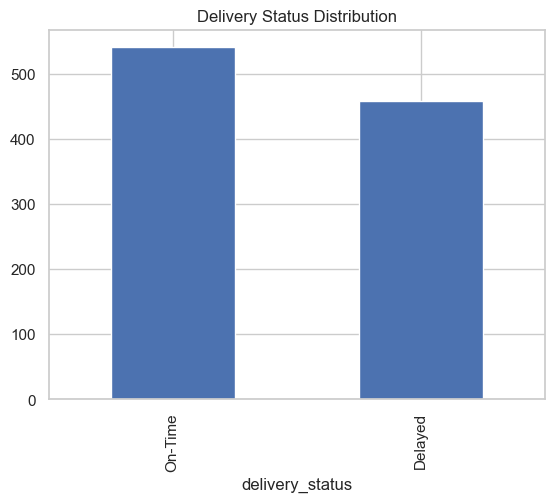

In [8]:
df['delivery_status'].value_counts().plot(kind='bar')
plt.title("Delivery Status Distribution")
plt.show()

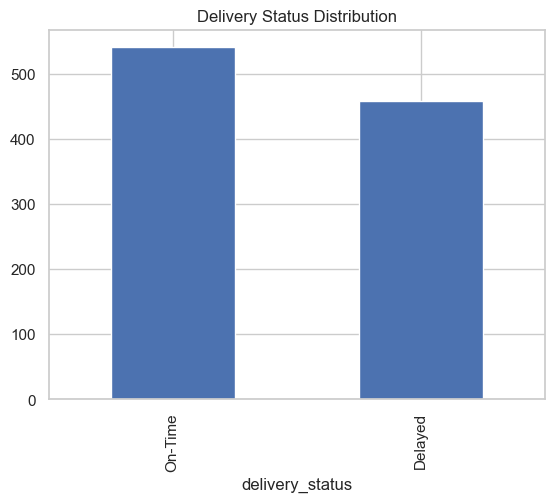

In [9]:
df['delivery_status'].value_counts().plot(kind='bar')
plt.title("Delivery Status Distribution")
plt.show()

In [10]:
delay_df = df.groupby('destination').agg(
    total=('shipment_id', 'count'),
    delayed=('delivery_status', lambda x: (x == 'Delayed').sum())
)

delay_df['delay_percentage'] = (delay_df['delayed'] / delay_df['total']) * 100
delay_df = delay_df.sort_values(by='delay_percentage', ascending=False)

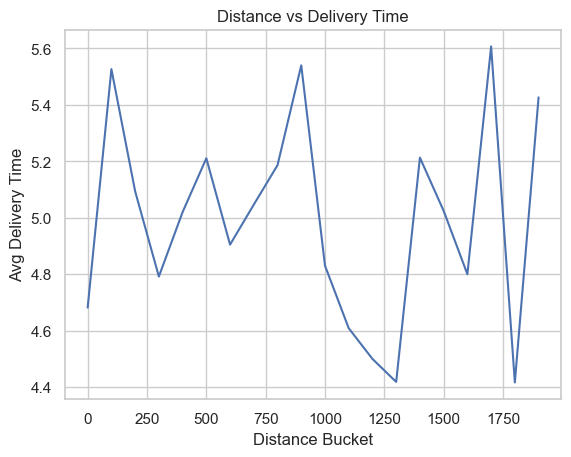

In [11]:
df['distance_bucket'] = (df['distance_km'] // 100) * 100

distance_df = df.groupby('distance_bucket')['delivery_time_days'].mean()

distance_df.plot()
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance Bucket")
plt.ylabel("Avg Delivery Time")
plt.show()

In [12]:
route_df = df.groupby(['origin', 'destination']).agg(
    total=('shipment_id', 'count'),
    delays=('delivery_status', lambda x: (x == 'Delayed').sum())
)

route_df = route_df.sort_values(by='delays', ascending=False)

route_df.head(10)

total  delays
origin    destination               
Mumbai    Pune           121      61
Delhi     Pune           108      59
          Chennai        112      54
Mumbai    Chennai        116      52
Bangalore Pune           113      51
          Chennai        120      48
Delhi     Hyderabad      108      48
Mumbai    Hyderabad      105      44
Bangalore Hyderabad       97      42

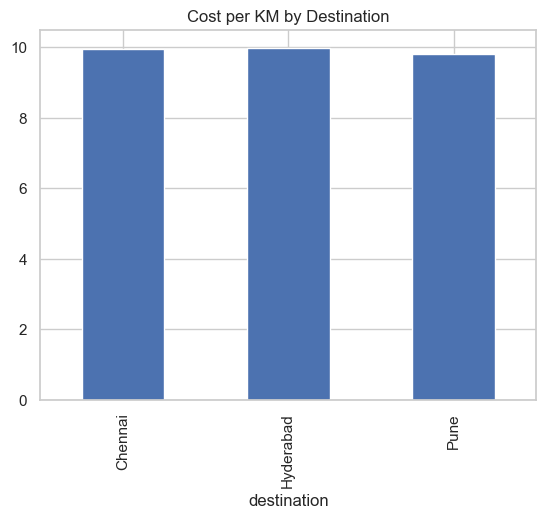

In [13]:
df['cost_per_km'] = df['transport_cost'] / df['distance_km']

df.groupby('destination')['cost_per_km'].mean().plot(kind='bar')
plt.title("Cost per KM by Destination")
plt.show()